<a href="https://colab.research.google.com/github/anmollate/Data-Science/blob/main/Log_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import FunctionTransformer

In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/anushnadhar/Titanic-dataset/refs/heads/main/titanic_dataset.csv",usecols=['Age','Fare','Survived'])

In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
df.isnull().sum()

,0
Survived,0
Age,263
Fare,1


In [ ]:
# df['Age'].fillna(df['Age'].mean(),inplace=True)
df.fillna({'Age':df['Age'].mean()},inplace=True)

In [ ]:
df["Age"].isnull().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,1


In [ ]:
df=df.dropna(subset=['Fare'])

In [ ]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [ ]:
x=df.drop('Survived', axis=1)
y=df['Survived']

In [ ]:
x.head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [ ]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [ ]:
#train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

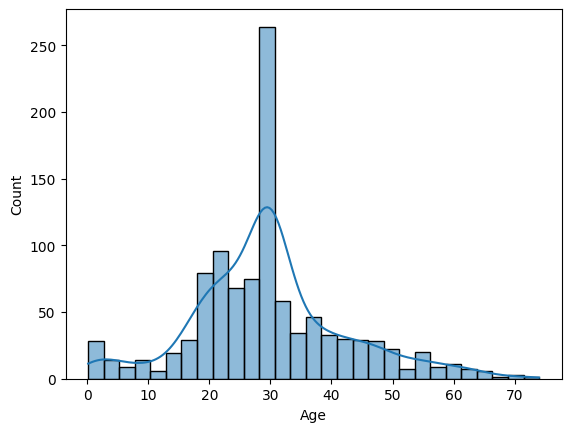

In [ ]:
#distribution of Age Column
sns.histplot(x_train['Age'],kde=True)
plt.show()

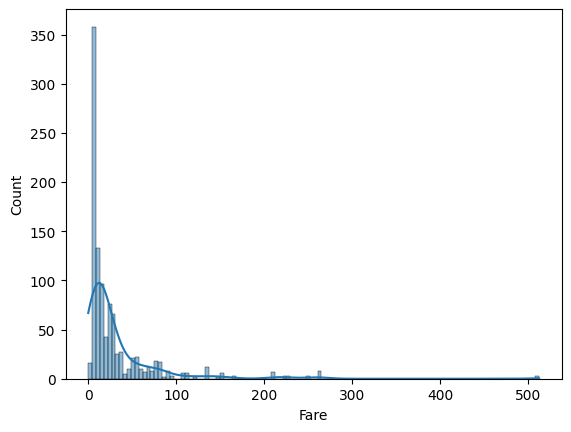

In [ ]:
#distribution of Fare Column
sns.histplot(x_train['Fare'],kde=True)
plt.show()

In [ ]:
#Not Applying Logistic Regression and Decisiontree Classifier On Pre-Transformed Data To Check Its Effect On Both After Transformation
LR=LogisticRegression()
DTC=DecisionTreeClassifier()

In [ ]:
LR.fit(x_train,y_train)

LogisticRegression()

In [ ]:
DTC.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_LR=LR.predict(x_test)
y_pred_DTC=DTC.predict(x_test)

In [ ]:
print("Accuracy For Logistic Regression Before Transformation:",accuracy_score(y_test,y_pred_LR))
print("Accuracy For Decision Tree Classifier Before Transformation:",accuracy_score(y_test,y_pred_DTC))

Accuracy For Logistic Regression Before Transformation: 0.583969465648855
Accuracy For Decision Tree Classifier Before Transformation: 0.6106870229007634


In [ ]:
#Log Transformation
trns=FunctionTransformer(func=np.log1p)

In [ ]:
x_train_trans=trns.fit_transform(x_train)
x_test_trans=trns.transform(x_test)

In [ ]:
LR2=LogisticRegression()
DTC2=DecisionTreeClassifier()

In [ ]:
LR2.fit(x_train_trans,y_train)

LogisticRegression()

In [ ]:
DTC2.fit(x_train_trans,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_LR2=LR2.predict(x_test_trans)
y_pred_DTC2=DTC.predict(x_test_trans)

In [ ]:
print("Accuracy For Logistic Regression After Transformation:",accuracy_score(y_test,y_pred_LR2))
print("Accuracy For Decision Tree Classifier After Transformation:",accuracy_score(y_test,y_pred_DTC2))

Accuracy For Logistic Regression After Transformation: 0.6526717557251909
Accuracy For Decision Tree Classifier After Transformation: 0.5534351145038168


In [ ]:
x_train.head()

,Age,Fare
770,24.0,9.500
543,32.0,26.000
289,22.0,7.750
10,4.0,16.700
147,9.0,34.375


In [ ]:
x_train['Fare']=trns.fit_transform(x_train['Fare'])

In [ ]:
x_test['Fare']=trns.transform(x_test['Fare'])

In [ ]:
x_train.head()

,Age,Fare
770,24.0,2.351375
543,32.0,3.295837
289,22.0,2.169054
10,4.0,2.873565
147,9.0,3.566005


In [ ]:
x_test.head()

,Age,Fare
1013,35.0,4.073291
1049,42.0,3.316003
695,52.0,2.674149
736,48.0,3.566005
723,50.0,2.639057


In [ ]:
lr=LogisticRegression()
dtc=DecisionTreeClassifier()

In [ ]:
lr.fit(x_train,y_train)
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_predlr=lr.predict(x_test)
y_preddtc=dtc.predict(x_test)

In [ ]:
print("Accuracy LR:",accuracy_score(y_test,y_predlr))
print("Accuracy DTC:",accuracy_score(y_test,y_preddtc))

Accuracy LR: 0.6183206106870229
Accuracy DTC: 0.6068702290076335
